# Fase 3, Paso 1 — Benchmark: Buy & Hold vs. DCA

Antes de tocar Machine Learning, establezco la "vara" contra la que cualquier modelo futuro tendrá que competir: ¿qué rendimiento da simplemente comprar el mercado y no hacer nada más?

**Nota sobre los datos:** el CSV crudo (`sp500_historico_raw.csv`, dataset público de Robert Shiller vía GitHub) lo descargué en un entorno donde sí tenía acceso a Yahoo Finance/GitHub sin restricciones, y no viaja con este repo. Este notebook parte directamente de `data/processed/sp500_historico.csv`, que ya es el resultado limpio de ese paso — así que corre igual sin necesidad de volver a descargar nada.

In [1]:
import sys
sys.path.insert(0, "../src")  # notebooks/ vive al lado de src/, sin instalar el paquete

import pandas as pd
import numpy as np
from scipy.optimize import brentq

from inversion import viz

CAPITAL_TOTAL = 10_000.0  # USD, monto total a invertir en ambos escenarios

## Cargar datos

In [2]:
df = pd.read_csv("../data/processed/sp500_historico.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

N = len(df)
APORTE_MENSUAL = CAPITAL_TOTAL / N
precios = df["cierre"].values
fechas = df["fecha"].values

print(f"Periodo: {df['fecha'].min().date()} a {df['fecha'].max().date()} ({N} meses)")
df.head()

Periodo: 2000-01-01 a 2026-08-01 (320 meses)


,fecha,cierre
0,2000-01-01,1425.59
1,2000-02-01,1388.87
2,2000-03-01,1442.21
3,2000-04-01,1461.36
4,2000-05-01,1418.48


## A) Buy & Hold (lump sum)

Todo el capital invertido de una sola vez al inicio.

In [3]:
unidades_bh = CAPITAL_TOTAL / precios[0]
valor_bh = unidades_bh * precios

valor_final_bh = valor_bh[-1]
años_bh = (fechas[-1] - fechas[0]) / np.timedelta64(365, "D")
cagr_bh = (valor_final_bh / CAPITAL_TOTAL) ** (1 / años_bh) - 1

pico_bh = np.maximum.accumulate(valor_bh)
drawdown_bh = (valor_bh - pico_bh) / pico_bh
max_drawdown_bh = drawdown_bh.min()

print(f"Valor final: ${valor_final_bh:,.0f}  CAGR: {cagr_bh:.2%}  Drawdown máximo: {max_drawdown_bh:.2%}")

Valor final: $54,092  CAGR: 6.55%  Drawdown máximo: -50.82%


## B) DCA (aportaciones mensuales iguales)

Mismo capital total, repartido en partes iguales a lo largo de todo el periodo. La métrica correcta aquí no es CAGR sino el rendimiento ponderado por dinero (IRR), porque el dinero entra en momentos distintos.

In [4]:
unidades_acumuladas = np.cumsum(APORTE_MENSUAL / precios)
valor_dca = unidades_acumuladas * precios

valor_final_dca = valor_dca[-1]
total_aportado_dca = APORTE_MENSUAL * N
aportado_acumulado = APORTE_MENSUAL * np.arange(1, N + 1)

pico_dca = np.maximum.accumulate(valor_dca)
drawdown_dca = (valor_dca - pico_dca) / pico_dca
max_drawdown_dca = drawdown_dca.min()

# IRR mensual -> anualizado: flujos negativos cada mes (aportación),
# un flujo positivo final (valor total)
flujos = [-APORTE_MENSUAL] * N
flujos[-1] += valor_final_dca


def van(tasa_mensual, flujos):
    return sum(f / (1 + tasa_mensual) ** i for i, f in enumerate(flujos))


# Límites (-0.5, 1.0): límites más amplios como -0.99 causan ZeroDivisionError
# por underflow de floats en periodos largos (320+ meses)
irr_mensual = brentq(lambda r: van(r, flujos), -0.5, 1.0)
irr_anual_dca = (1 + irr_mensual) ** 12 - 1

print(f"Valor final: ${valor_final_dca:,.0f}  IRR anualizado: {irr_anual_dca:.2%}  Drawdown máximo: {max_drawdown_dca:.2%}")

Valor final: $45,546  IRR anualizado: 9.96%  Drawdown máximo: -41.46%


## Resumen comparativo

In [5]:
resumen = pd.DataFrame({
    "Escenario": ["Buy & Hold (lump sum)", "DCA (mensual)"],
    "Capital total invertido (USD)": [CAPITAL_TOTAL, total_aportado_dca],
    "Valor final (USD)": [valor_final_bh, valor_final_dca],
    "Ganancia (USD)": [valor_final_bh - CAPITAL_TOTAL, valor_final_dca - total_aportado_dca],
    "CAGR / Rendimiento anualizado": [cagr_bh, irr_anual_dca],
    "Drawdown máximo": [max_drawdown_bh, max_drawdown_dca],
})

series = pd.DataFrame({
    "fecha": df["fecha"],
    "valor_buy_and_hold": valor_bh,
    "valor_dca": valor_dca,
    "aportado_acumulado_dca": aportado_acumulado,
})
series.to_csv("../outputs/series/series_comparacion.csv", index=False)
resumen.to_csv("../outputs/metrics/resumen_metricas.csv", index=False)

resumen.style.format({
    "Capital total invertido (USD)": "${:,.0f}".format,
    "Valor final (USD)": "${:,.0f}".format,
    "Ganancia (USD)": "${:,.0f}".format,
    "CAGR / Rendimiento anualizado": "{:.2%}".format,
    "Drawdown máximo": "{:.2%}".format,
})

,Escenario,Capital total invertido (USD),Valor final (USD),Ganancia (USD),CAGR / Rendimiento anualizado,Drawdown máximo
0,Buy & Hold (lump sum),"$10,000","$54,092","$44,092",6.55%,-50.82%
1,DCA (mensual),"$10,000","$45,546","$35,546",9.96%,-41.46%


## Gráfica: valor del portafolio y drawdown

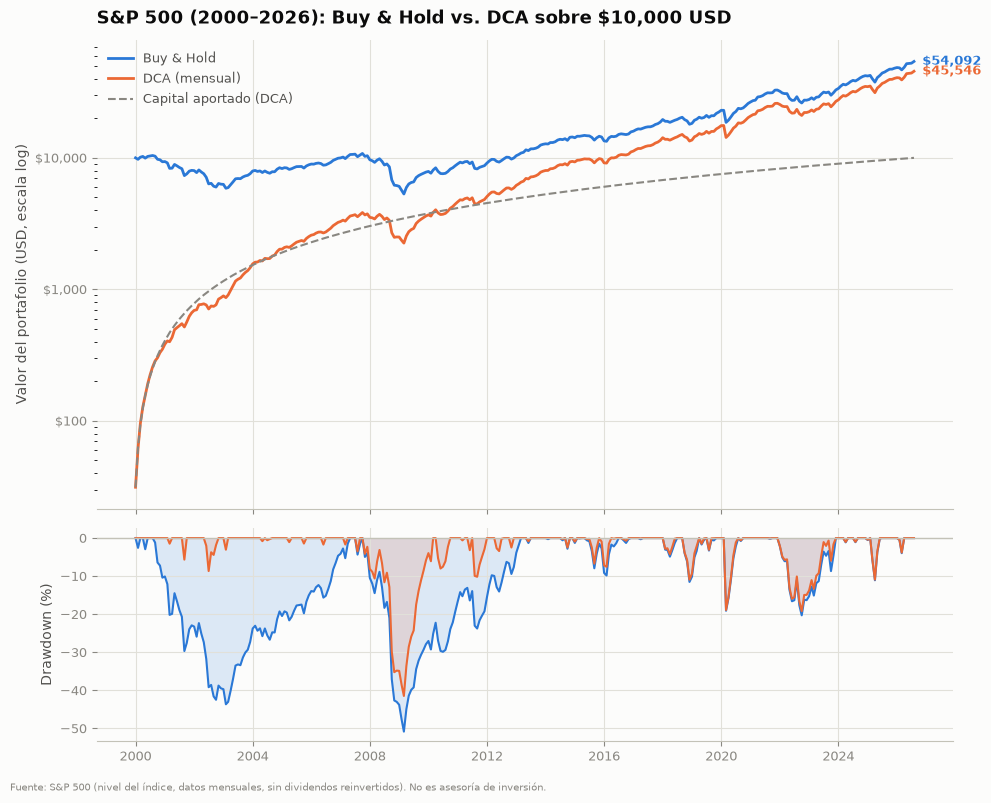

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]}, facecolor=viz.SURFACE,
)

ax1.set_facecolor(viz.SURFACE)
ax1.plot(series["fecha"], series["valor_buy_and_hold"], color=viz.COLOR_BUY_AND_HOLD, linewidth=2, label="Buy & Hold")
ax1.plot(series["fecha"], series["valor_dca"], color=viz.COLOR_DCA, linewidth=2, label="DCA (mensual)")
ax1.plot(series["fecha"], series["aportado_acumulado_dca"], color=viz.INK_MUTED, linewidth=1.5,
         linestyle="--", label="Capital aportado (DCA)")
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_ylabel("Valor del portafolio (USD, escala log)", color=viz.INK_SECONDARY, fontsize=10)
ax1.set_title("S&P 500 (2000–2026): Buy & Hold vs. DCA sobre $10,000 USD",
              color=viz.INK_PRIMARY, fontsize=13, fontweight="bold", loc="left", pad=12)
ax1.grid(True, color=viz.GRID, linewidth=0.8)
ax1.tick_params(colors=viz.INK_MUTED, labelsize=9)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.spines["bottom"].set_visible(True)
ax1.spines["bottom"].set_color(viz.BASELINE)
ax1.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=viz.INK_SECONDARY)

for serie, color in [("valor_buy_and_hold", viz.COLOR_BUY_AND_HOLD), ("valor_dca", viz.COLOR_DCA)]:
    ax1.annotate(f"${series[serie].iloc[-1]:,.0f}", xy=(series["fecha"].iloc[-1], series[serie].iloc[-1]),
                 xytext=(6, 0), textcoords="offset points",
                 color=color, fontsize=9, fontweight="bold", va="center")

ax2.set_facecolor(viz.SURFACE)
dd_bh_s = (series["valor_buy_and_hold"] - series["valor_buy_and_hold"].cummax()) / series["valor_buy_and_hold"].cummax()
dd_dca_s = (series["valor_dca"] - series["valor_dca"].cummax()) / series["valor_dca"].cummax()
ax2.fill_between(series["fecha"], dd_bh_s * 100, 0, color=viz.COLOR_BUY_AND_HOLD, alpha=0.15, linewidth=0)
ax2.plot(series["fecha"], dd_bh_s * 100, color=viz.COLOR_BUY_AND_HOLD, linewidth=1.5)
ax2.fill_between(series["fecha"], dd_dca_s * 100, 0, color=viz.COLOR_DCA, alpha=0.15, linewidth=0)
ax2.plot(series["fecha"], dd_dca_s * 100, color=viz.COLOR_DCA, linewidth=1.5)
ax2.axhline(0, color=viz.BASELINE, linewidth=1)
ax2.set_ylabel("Drawdown (%)", color=viz.INK_SECONDARY, fontsize=10)
ax2.grid(True, color=viz.GRID, linewidth=0.8)
ax2.tick_params(colors=viz.INK_MUTED, labelsize=9)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.spines["bottom"].set_visible(True)
ax2.spines["bottom"].set_color(viz.BASELINE)

fig.text(0.01, 0.005,
         "Fuente: S&P 500 (nivel del índice, datos mensuales, sin dividendos reinvertidos). "
         "No es asesoría de inversión.", fontsize=7.5, color=viz.INK_MUTED)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("../outputs/figures/comparacion_buyhold_vs_dca.png", dpi=160, facecolor=viz.SURFACE, bbox_inches="tight")
plt.show()

## Lectura

Buy & Hold terminó con más dinero en términos absolutos porque estuvo expuesto al mercado los 26.6 años completos. DCA tuvo un drawdown máximo menor (evitó invertir todo justo antes de la caída de 2000-2002) y, medido en la métrica correcta para dinero que entra en momentos distintos (IRR), cada dólar de DCA rindió más por año. Ninguno "gana" en automático — son trade-offs distintos entre rendimiento total y control de riesgo.

**Este benchmark es la vara contra la que se mide cualquier modelo futuro:** si un modelo no le gana de forma consistente y validada, el benchmark gana por defecto.